# F1 2026 — Performance & Strategy Analysis

This notebook analyzes the cleaned Australia, China and Japan race dataset.

Questions:
- Which drivers show the strongest race pace?
- Which drivers are most consistent?
- How does tyre age affect lap time?
- Which compounds perform best?
- How do drivers and teams compare across circuits?
- Which drivers gain or lose pace as a race progresses?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"

print("Analysis environment ready.")


Analysis environment ready.


## 1. Load the combined dataset


In [2]:
file_path = PROCESSED_DATA / "f1_2026_three_races.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
display(df.head())


Shape: (3037, 43)


,time,lap,compound,stint,s1,s2,s3,ms1,ms2,ms3,life,pos,status,pb,sesT,drv,dNum,pout,pin,s1T,s2T,s3T,vi1,vi2,vfl,vst,fresh,team,lST,lSD,del,delR,ff1G,iacc,wT,wAT,wH,wP,wR,wTT,wWD,wWS,race
0,99.376,1,MEDIUM,1,NaN,19.018,39.109,77777777.0,0.0,7.700000e+01,1,12.0,1,False,3839.355,ALB,23,NaN,NaN,NaN,3800.705,3839.566,225.0,290.0,291.0,209.0,True,Williams,3739.743,2026-03-08T04:03:26.366000000,False,NaN,False,False,3793.796,24.2,54.0,1012.8,False,36.6,104,4.4,Australian Grand Prix
1,87.780,2,MEDIUM,1,31.155,18.160,38.465,100111.0,10001.0,1.011010e+09,2,13.0,1,True,3927.135,ALB,23,NaN,NaN,3870.594,3888.754,3927.219,259.0,285.0,281.0,265.0,True,Williams,3839.355,2026-03-08T04:05:05.978000000,False,NaN,False,True,3853.794,24.2,54.4,1012.8,False,36.0,135,2.3,Australian Grand Prix
2,87.512,3,MEDIUM,1,31.369,18.234,37.909,111100110.0,1.0,1.101100e+04,3,13.0,1,True,4014.647,ALB,23,NaN,NaN,3958.588,3976.822,4014.731,267.0,310.0,301.0,251.0,True,Williams,3927.135,2026-03-08T04:06:33.758000000,False,NaN,False,True,3973.816,24.1,54.1,1012.9,False,36.1,112,1.6,Australian Grand Prix
3,87.911,4,MEDIUM,1,30.836,18.153,38.922,1311011.0,1.0,1.000010e+08,4,14.0,1,False,4102.558,ALB,23,NaN,NaN,4045.567,4063.720,4102.642,255.0,293.0,301.0,276.0,True,Williams,4014.647,2026-03-08T04:08:01.270000000,False,NaN,False,True,4033.811,24.1,54.1,1012.9,False,36.1,112,1.6,Australian Grand Prix
4,87.176,5,MEDIUM,1,30.385,18.275,38.516,710011010.0,11000.0,1.010010e+09,5,13.0,1,True,4189.734,ALB,23,NaN,NaN,4133.027,4151.302,4189.818,260.0,318.0,292.0,278.0,True,Williams,4102.558,2026-03-08T04:09:29.181000000,False,NaN,False,True,4153.828,24.2,54.2,1012.8,False,35.1,127,2.2,Australian Grand Prix


In [3]:
print("Races:")
print(df["race"].value_counts())

print("\nDrivers:", df["drv"].nunique())
print("Teams:", df["team"].nunique())

print("\nRows by race:")
display(df.groupby("race").size().reset_index(name="lap_records"))


Races:
race
Japanese Grand Prix      1108
Australian Grand Prix    1008
Chinese Grand Prix        921
Name: count, dtype: int64

Drivers: 22
Teams: 11

Rows by race:


,race,lap_records
0,Australian Grand Prix,1008
1,Chinese Grand Prix,921
2,Japanese Grand Prix,1108


## 2. Prepare valid lap records


In [4]:
analysis_df = df.copy()

for col in ["time", "lap", "life", "stint", "pos", "s1", "s2", "s3"]:
    if col in analysis_df.columns:
        analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

analysis_df = analysis_df.dropna(
    subset=["time", "drv", "team", "race"]
).copy()

print("Valid lap records:", len(analysis_df))
display(analysis_df.head())


Valid lap records: 3028


,time,lap,compound,stint,s1,s2,s3,ms1,ms2,ms3,life,pos,status,pb,sesT,drv,dNum,pout,pin,s1T,s2T,s3T,vi1,vi2,vfl,vst,fresh,team,lST,lSD,del,delR,ff1G,iacc,wT,wAT,wH,wP,wR,wTT,wWD,wWS,race
0,99.376,1,MEDIUM,1,NaN,19.018,39.109,77777777.0,0.0,7.700000e+01,1,12.0,1,False,3839.355,ALB,23,NaN,NaN,NaN,3800.705,3839.566,225.0,290.0,291.0,209.0,True,Williams,3739.743,2026-03-08T04:03:26.366000000,False,NaN,False,False,3793.796,24.2,54.0,1012.8,False,36.6,104,4.4,Australian Grand Prix
1,87.780,2,MEDIUM,1,31.155,18.160,38.465,100111.0,10001.0,1.011010e+09,2,13.0,1,True,3927.135,ALB,23,NaN,NaN,3870.594,3888.754,3927.219,259.0,285.0,281.0,265.0,True,Williams,3839.355,2026-03-08T04:05:05.978000000,False,NaN,False,True,3853.794,24.2,54.4,1012.8,False,36.0,135,2.3,Australian Grand Prix
2,87.512,3,MEDIUM,1,31.369,18.234,37.909,111100110.0,1.0,1.101100e+04,3,13.0,1,True,4014.647,ALB,23,NaN,NaN,3958.588,3976.822,4014.731,267.0,310.0,301.0,251.0,True,Williams,3927.135,2026-03-08T04:06:33.758000000,False,NaN,False,True,3973.816,24.1,54.1,1012.9,False,36.1,112,1.6,Australian Grand Prix
3,87.911,4,MEDIUM,1,30.836,18.153,38.922,1311011.0,1.0,1.000010e+08,4,14.0,1,False,4102.558,ALB,23,NaN,NaN,4045.567,4063.720,4102.642,255.0,293.0,301.0,276.0,True,Williams,4014.647,2026-03-08T04:08:01.270000000,False,NaN,False,True,4033.811,24.1,54.1,1012.9,False,36.1,112,1.6,Australian Grand Prix
4,87.176,5,MEDIUM,1,30.385,18.275,38.516,710011010.0,11000.0,1.010010e+09,5,13.0,1,True,4189.734,ALB,23,NaN,NaN,4133.027,4151.302,4189.818,260.0,318.0,292.0,278.0,True,Williams,4102.558,2026-03-08T04:09:29.181000000,False,NaN,False,True,4153.828,24.2,54.2,1012.8,False,35.1,127,2.2,Australian Grand Prix


## 3. Driver race pace


In [5]:
driver_pace = (
    analysis_df.groupby(["drv", "team"])
    .agg(
        races=("race", "nunique"),
        laps=("time", "count"),
        best_lap=("time", "min"),
        average_lap=("time", "mean"),
        median_lap=("time", "median"),
        pace_std=("time", "std")
    )
    .reset_index()
    .sort_values("average_lap")
)

display(driver_pace)


,drv,team,races,laps,best_lap,average_lap,median_lap,pace_std
14,NOR,McLaren,2,111,82.358,93.202018,93.3980,13.889524
4,BOR,Audi,2,110,83.257,94.018700,94.6135,13.101245
3,BEA,Haas F1 Team,3,133,84.020,94.801797,96.7780,10.994955
2,ANT,Mercedes,3,167,82.417,95.022665,94.4750,14.891825
18,RUS,Mercedes,3,167,82.670,95.132216,94.7880,14.472351
12,LEC,Ferrari,3,167,82.579,95.362240,95.1260,13.899071
9,HAM,Ferrari,3,167,82.423,95.402749,95.1660,14.304423
0,ALB,Williams,2,108,84.375,95.660611,95.0045,14.018081
21,VER,Red Bull Racing,3,156,82.091,96.178173,95.5870,14.533929
7,GAS,Alpine,3,166,84.486,96.306175,95.7595,13.489675


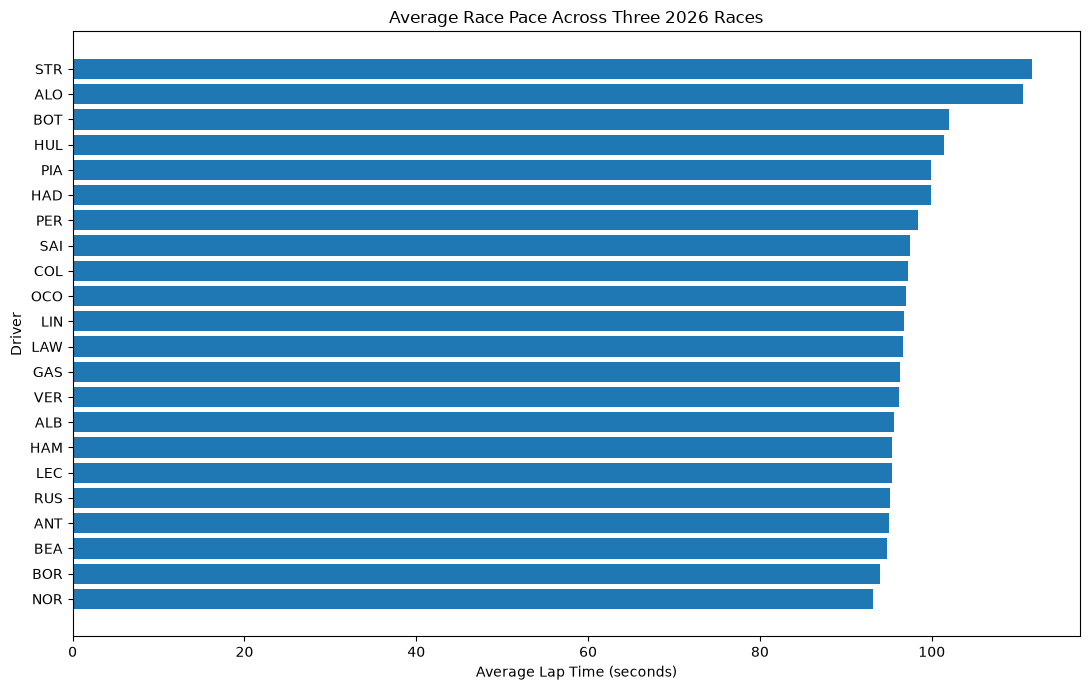

In [6]:
plot_df = driver_pace.sort_values("average_lap", ascending=True)

plt.figure(figsize=(11, 7))
plt.barh(plot_df["drv"], plot_df["average_lap"])
plt.xlabel("Average Lap Time (seconds)")
plt.ylabel("Driver")
plt.title("Average Race Pace Across Three 2026 Races")
plt.tight_layout()
plt.show()


## 4. Driver performance by circuit


In [7]:
race_driver_pace = (
    analysis_df.groupby(["race", "drv", "team"])
    .agg(
        laps=("time", "count"),
        best_lap=("time", "min"),
        average_lap=("time", "mean"),
        median_lap=("time", "median"),
        pace_std=("time", "std")
    )
    .reset_index()
)

display(race_driver_pace.sort_values(["race", "average_lap"]))

pace_matrix = race_driver_pace.pivot_table(
    index="drv", columns="race", values="average_lap"
)
display(pace_matrix)


,race,drv,team,laps,best_lap,average_lap,median_lap,pace_std
16,Australian Grand Prix,RUS,Mercedes,58,82.670,85.979328,83.1675,8.415193
2,Australian Grand Prix,ANT,Mercedes,58,82.417,86.030603,83.0910,8.860910
11,Australian Grand Prix,LEC,Ferrari,58,82.579,86.246897,83.3430,7.439266
9,Australian Grand Prix,HAM,Ferrari,58,82.423,86.257672,83.4915,7.650691
8,Australian Grand Prix,HAD,Red Bull Racing,10,85.239,86.552500,85.4040,3.344903
13,Australian Grand Prix,NOR,McLaren,58,82.358,86.871414,83.9040,8.449060
19,Australian Grand Prix,VER,Red Bull Racing,58,82.091,86.921000,83.6950,8.241412
3,Australian Grand Prix,BEA,Haas F1 Team,57,84.020,87.568316,84.8070,7.612000
12,Australian Grand Prix,LIN,Racing Bulls,57,84.182,87.695035,84.9160,7.447796
4,Australian Grand Prix,BOR,Audi,57,83.257,87.711860,84.8300,8.032040


race,Australian Grand Prix,Chinese Grand Prix,Japanese Grand Prix
drv,,,
ALB,88.471509,NaN,103.695490
ALO,138.370905,106.236969,102.114442
ANT,86.030603,99.921554,99.686849
BEA,87.568316,100.944196,98.218500
BOR,87.711860,NaN,100.801528
BOT,98.127400,102.759364,102.423538
COL,89.201571,101.963818,100.927849
GAS,87.996982,100.986679,100.297038
HAD,86.552500,101.479536,100.746358


## 5. Driver consistency


In [8]:
consistency = (
    analysis_df.groupby(["race", "drv", "team"])
    .agg(
        average_lap=("time", "mean"),
        lap_time_std=("time", "std"),
        laps=("time", "count")
    )
    .reset_index()
)

display(consistency.sort_values(["race", "lap_time_std"]))


,race,drv,team,average_lap,lap_time_std,laps
8,Australian Grand Prix,HAD,Red Bull Racing,86.552500,3.344903,10
14,Australian Grand Prix,OCO,Haas F1 Team,88.011421,7.287612,57
7,Australian Grand Prix,GAS,Alpine,87.996982,7.351476,57
11,Australian Grand Prix,LEC,Ferrari,86.246897,7.439266,58
12,Australian Grand Prix,LIN,Racing Bulls,87.695035,7.447796,57
3,Australian Grand Prix,BEA,Haas F1 Team,87.568316,7.612000,57
9,Australian Grand Prix,HAM,Ferrari,86.257672,7.650691,58
15,Australian Grand Prix,PER,Cadillac,90.811836,7.852015,55
4,Australian Grand Prix,BOR,Audi,87.711860,8.032040,57
0,Australian Grand Prix,ALB,Williams,88.471509,8.111483,57


## 6. Tyre compound performance


In [9]:
compound_analysis = (
    analysis_df.dropna(subset=["compound"])
    .groupby(["race", "compound"])
    .agg(
        laps=("time", "count"),
        drivers=("drv", "nunique"),
        average_lap=("time", "mean"),
        median_lap=("time", "median"),
        best_lap=("time", "min")
    )
    .reset_index()
)

display(compound_analysis)

display(
    compound_analysis.pivot_table(
        index="compound",
        columns="race",
        values="average_lap"
    )
)


,race,compound,laps,drivers,average_lap,median_lap,best_lap
0,Australian Grand Prix,HARD,588,18,87.740609,84.9355,82.091
1,Australian Grand Prix,MEDIUM,285,17,89.355379,85.6390,82.358
2,Australian Grand Prix,SOFT,130,7,103.366469,86.0670,82.926
3,Chinese Grand Prix,HARD,727,18,101.993450,98.3890,95.275
4,Chinese Grand Prix,MEDIUM,173,15,100.654422,98.3710,96.099
5,Chinese Grand Prix,SOFT,19,3,102.471316,99.1200,95.964
6,Japanese Grand Prix,HARD,609,22,102.664054,94.8720,92.432
7,Japanese Grand Prix,MEDIUM,493,22,98.545572,96.7590,93.427
8,Japanese Grand Prix,SOFT,4,1,120.247250,118.5595,116.651


race,Australian Grand Prix,Chinese Grand Prix,Japanese Grand Prix
compound,,,
HARD,87.740609,101.993450,102.664054
MEDIUM,89.355379,100.654422,98.545572
SOFT,103.366469,102.471316,120.247250


## 7. Tyre age and degradation


In [10]:
degradation = (
    analysis_df.dropna(subset=["life"])
    .groupby(["race", "compound", "life"])
    .agg(
        average_lap=("time", "mean"),
        median_lap=("time", "median"),
        observations=("time", "count")
    )
    .reset_index()
)

display(degradation.head(40))


,race,compound,life,average_lap,median_lap,observations
0,Australian Grand Prix,HARD,1,109.107550,116.0420,20
1,Australian Grand Prix,HARD,2,91.887200,86.7535,20
2,Australian Grand Prix,HARD,3,84.996650,84.9810,20
3,Australian Grand Prix,HARD,4,85.152350,84.6255,20
4,Australian Grand Prix,HARD,5,85.223800,84.9245,20
5,Australian Grand Prix,HARD,6,87.608150,85.4595,20
6,Australian Grand Prix,HARD,7,94.821050,87.2750,20
7,Australian Grand Prix,HARD,8,92.762650,86.5910,20
8,Australian Grand Prix,HARD,9,87.024800,85.0695,20
9,Australian Grand Prix,HARD,10,85.300250,84.6925,20


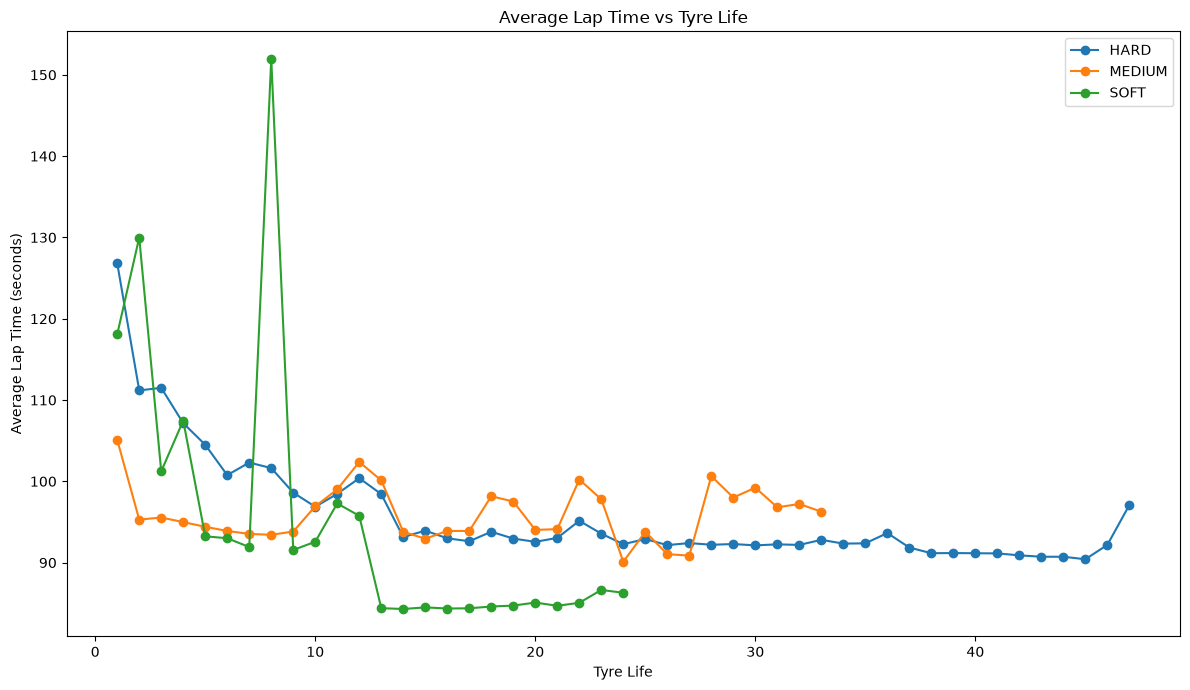

In [11]:
common_compounds = analysis_df["compound"].dropna().value_counts().head(3).index

plt.figure(figsize=(12, 7))

for compound in common_compounds:
    temp = (
        degradation[degradation["compound"] == compound]
        .groupby("life", as_index=False)["average_lap"]
        .mean()
        .sort_values("life")
    )
    plt.plot(temp["life"], temp["average_lap"], marker="o", label=str(compound))

plt.xlabel("Tyre Life")
plt.ylabel("Average Lap Time (seconds)")
plt.title("Average Lap Time vs Tyre Life")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Stint performance


In [12]:
stint_analysis = (
    analysis_df.dropna(subset=["stint", "compound"])
    .groupby(["race", "drv", "stint", "compound"])
    .agg(
        laps=("lap", "count"),
        average_lap=("time", "mean"),
        best_lap=("time", "min"),
        first_lap_time=("time", "first"),
        last_lap_time=("time", "last"),
        average_tyre_life=("life", "mean")
    )
    .reset_index()
)

stint_analysis["pace_change"] = (
    stint_analysis["last_lap_time"] - stint_analysis["first_lap_time"]
)

display(stint_analysis.head(50))


,race,drv,stint,compound,laps,average_lap,best_lap,first_lap_time,last_lap_time,average_tyre_life,pace_change
0,Australian Grand Prix,ALB,1,MEDIUM,12,91.562750,85.558,99.376,125.578,6.5,26.202
1,Australian Grand Prix,ALB,2,HARD,21,90.294381,85.035,112.348,110.030,11.0,-2.318
2,Australian Grand Prix,ALB,3,SOFT,24,85.330875,84.375,90.918,86.268,12.5,-4.650
3,Australian Grand Prix,ALO,1,SOFT,11,91.645364,86.792,98.271,119.990,6.0,21.719
4,Australian Grand Prix,ALO,2,SOFT,2,595.935500,122.340,122.340,1069.531,1.5,947.191
5,Australian Grand Prix,ALO,3,SOFT,8,88.227375,85.713,98.828,88.082,6.5,-10.746
6,Australian Grand Prix,ANT,1,MEDIUM,12,89.377250,83.683,96.966,129.682,6.5,32.716
7,Australian Grand Prix,ANT,2,HARD,46,85.157565,82.417,117.691,82.653,23.5,-35.038
8,Australian Grand Prix,BEA,1,MEDIUM,18,91.169833,84.562,99.765,107.604,9.5,7.839
9,Australian Grand Prix,BEA,2,HARD,39,85.906077,84.020,116.677,86.649,20.0,-30.028


## 9. Team performance


In [13]:
team_performance = (
    analysis_df.groupby(["race", "team"])
    .agg(
        drivers=("drv", "nunique"),
        laps=("time", "count"),
        best_lap=("time", "min"),
        average_lap=("time", "mean"),
        median_lap=("time", "median"),
        pace_std=("time", "std")
    )
    .reset_index()
)

display(team_performance.sort_values(["race", "average_lap"]))


,race,team,drivers,laps,best_lap,average_lap,median_lap,pace_std
7,Australian Grand Prix,Mercedes,2,116,82.417,86.004966,83.1145,8.603313
4,Australian Grand Prix,Ferrari,2,116,82.423,86.252284,83.4140,7.512842
9,Australian Grand Prix,Red Bull Racing,2,68,82.091,86.866809,84.0325,7.700885
6,Australian Grand Prix,McLaren,1,58,82.358,86.871414,83.9040,8.449060
2,Australian Grand Prix,Audi,1,57,83.257,87.711860,84.8300,8.032040
5,Australian Grand Prix,Haas F1 Team,2,114,84.020,87.789868,85.1905,7.421864
8,Australian Grand Prix,Racing Bulls,2,114,83.783,88.092904,85.2215,8.147620
0,Australian Grand Prix,Alpine,2,113,82.926,88.593947,85.6780,7.782265
10,Australian Grand Prix,Williams,2,113,83.590,89.084628,85.7340,8.569078
3,Australian Grand Prix,Cadillac,2,70,86.070,92.379457,88.0945,14.153928


## 10. Teammate comparison


In [14]:
teammate = (
    analysis_df.groupby(["race", "team", "drv"])
    .agg(
        average_lap=("time", "mean"),
        best_lap=("time", "min"),
        laps=("time", "count")
    )
    .reset_index()
)

teammate["team_average"] = (
    teammate.groupby(["race", "team"])["average_lap"].transform("mean")
)

teammate["difference_to_team_average"] = (
    teammate["average_lap"] - teammate["team_average"]
)

display(
    teammate.sort_values(
        ["race", "team", "difference_to_team_average"]
    )
)


,race,team,drv,average_lap,best_lap,laps,team_average,difference_to_team_average
1,Australian Grand Prix,Alpine,GAS,87.996982,84.486,57,88.599277,-0.602294
0,Australian Grand Prix,Alpine,COL,89.201571,82.926,56,88.599277,0.602294
3,Australian Grand Prix,Aston Martin,STR,117.856605,85.410,43,128.113755,-10.257150
2,Australian Grand Prix,Aston Martin,ALO,138.370905,85.713,21,128.113755,10.257150
4,Australian Grand Prix,Audi,BOR,87.711860,83.257,57,87.711860,0.000000
6,Australian Grand Prix,Cadillac,PER,90.811836,86.070,55,94.469618,-3.657782
5,Australian Grand Prix,Cadillac,BOT,98.127400,87.364,15,94.469618,3.657782
8,Australian Grand Prix,Ferrari,LEC,86.246897,82.579,58,86.252284,-0.005388
7,Australian Grand Prix,Ferrari,HAM,86.257672,82.423,58,86.252284,0.005388
9,Australian Grand Prix,Haas F1 Team,BEA,87.568316,84.020,57,87.789868,-0.221553


## 11. Race progression


In [15]:
progression = analysis_df.copy()

progression["race_phase"] = pd.cut(
    progression["lap"],
    bins=[0, 15, 30, 1000],
    labels=["Early", "Middle", "Late"],
    include_lowest=True
)

phase_analysis = (
    progression.groupby(["race", "drv", "race_phase"], observed=True)
    .agg(
        average_lap=("time", "mean"),
        laps=("time", "count")
    )
    .reset_index()
)

display(phase_analysis.head(50))


,race,drv,race_phase,average_lap,laps
0,Australian Grand Prix,ALB,Early,92.101000,15
1,Australian Grand Prix,ALB,Middle,88.693867,15
2,Australian Grand Prix,ALB,Late,86.331593,27
3,Australian Grand Prix,ALO,Early,158.967400,15
4,Australian Grand Prix,ALO,Middle,86.879667,6
5,Australian Grand Prix,ANT,Early,90.678933,15
6,Australian Grand Prix,ANT,Middle,86.186200,15
7,Australian Grand Prix,ANT,Late,83.457071,28
8,Australian Grand Prix,BEA,Early,90.938867,15
9,Australian Grand Prix,BEA,Middle,88.217133,15


In [16]:
phase_pivot = phase_analysis.pivot_table(
    index=["race", "drv"],
    columns="race_phase",
    values="average_lap"
)

if {"Early", "Late"}.issubset(phase_pivot.columns):
    phase_pivot["late_minus_early"] = (
        phase_pivot["Late"] - phase_pivot["Early"]
    )

display(phase_pivot.sort_values("late_minus_early" if "late_minus_early" in phase_pivot else phase_pivot.columns[0]))


C:\Users\AnjuChinju\AppData\Local\Temp\ipykernel_16656\4116733003.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  phase_pivot = phase_analysis.pivot_table(


race_phase                      Early      Middle        Late  late_minus_early
race                  drv                                                      
Chinese Grand Prix    RUS  110.386800   96.913400   95.831500        -14.555300
                      ANT  110.143267   96.632267   95.922077        -14.221190
                      HAM  110.176800   97.236733   96.525808        -13.650992
                      GAS  110.543267   98.450933   96.936192        -13.607074
                      LEC  110.291733   97.068067   96.696308        -13.595426
                      BEA  110.497933   97.958600   97.154885        -13.343049
                      LAW  110.625400   98.640867   97.584654        -13.040746
                      HAD  110.693933   98.665067   97.787269        -12.906664
                      SAI  110.660933   99.083267   98.444680        -12.216253
                      LIN  110.465267   99.950600   98.487880        -11.977387
                      COL  110.261133   98.826800   98.867640        -11.393493
                      HUL  110.520800   98.630733   99.177720        -11.343080
                      BOT  110.820400   99.942333   99.612960        -11.207440
                      PER  110.890000  100.046333  100.248120        -10.641880
                      OCO  110.343133  100.504133   99.966160        -10.376973
                      VER  110.575600   98.032733  101.144800         -9.430800
Australian Grand Prix ANT   90.678933   86.186200   83.457071         -7.221862
                      COL   93.916133   88.424067   86.930192         -6.985941
                      NOR   91.317133   86.845333   84.503750         -6.813383
                      RUS   90.296933   86.134933   83.582964         -6.713969
                      LAW   92.769933   88.588667   86.059074         -6.710859
                      VER   90.820133   87.517067   84.512857         -6.307276
                      HAM   89.685333   88.154667   83.405179         -6.280155
                      GAS   91.853733   87.957733   85.876148         -5.977585
                      LEC   89.557600   87.835867   83.622071         -5.935529
                      OCO   91.746667   88.109400   85.881852         -5.864815
                      ALB   92.101000   88.693867   86.331593         -5.769407
                      BOR   91.061800   88.423333   85.455519         -5.606281
                      BEA   90.938867   88.217133   85.335333         -5.603533
                      LIN   90.667000   88.420267   85.641037         -5.025963
                      PER   92.756267   91.769733   89.070440         -3.685827
                      SAI   92.166400   88.719667   88.861385         -3.305015
Japanese Grand Prix   HUL   97.529667  113.158133   94.581130         -2.948536
                      SAI   97.651867  113.098867   95.093478         -2.558388
                      ANT   95.431133  114.248133   92.965826         -2.465307
                      LAW   97.167467  113.187133   94.707130         -2.460336
                      PER   98.524733  112.395000   96.176522         -2.348212
                      VER   96.331400  113.920133   94.013348         -2.318052
                      BOR   97.258933  113.323000   94.945739         -2.313194
                      HAD   97.074200  113.539800   94.797696         -2.276504
                      LIN   97.061000  113.616600   94.916826         -2.144174
                      COL   97.231200  113.564067   95.097696         -2.133504
                      OCO   96.796800  113.613333   94.715957         -2.080843
                      GAS   96.068400  114.162333   94.012261         -2.056139
                      LEC   95.444133  114.555267   93.420957         -2.023177
                      BOT   99.411067  112.568867   97.560227         -1.850839
                      NOR   95.512333  114.561333   93.729435         -1.782899
                      RUS   95.207333  114.744067   93.473304         -1.734029


## 12. Project leaderboard


In [17]:
leaderboard = (
    analysis_df.groupby(["drv", "team"])
    .agg(
        races=("race", "nunique"),
        laps=("time", "count"),
        average_lap=("time", "mean"),
        best_lap=("time", "min"),
        consistency=("time", "std")
    )
    .reset_index()
)

leaderboard["pace_rank"] = leaderboard["average_lap"].rank(method="min")
leaderboard["consistency_rank"] = leaderboard["consistency"].rank(method="min")

leaderboard = leaderboard.sort_values("pace_rank")
display(leaderboard)


,drv,team,races,laps,average_lap,best_lap,consistency,pace_rank,consistency_rank
14,NOR,McLaren,2,111,93.202018,82.358,13.889524,1.0,12.0
4,BOR,Audi,2,110,94.018700,83.257,13.101245,2.0,9.0
3,BEA,Haas F1 Team,3,133,94.801797,84.020,10.994955,3.0,1.0
2,ANT,Mercedes,3,167,95.022665,82.417,14.891825,4.0,19.0
18,RUS,Mercedes,3,167,95.132216,82.670,14.472351,5.0,17.0
12,LEC,Ferrari,3,167,95.362240,82.579,13.899071,6.0,13.0
9,HAM,Ferrari,3,167,95.402749,82.423,14.304423,7.0,16.0
0,ALB,Williams,2,108,95.660611,84.375,14.018081,8.0,15.0
21,VER,Red Bull Racing,3,156,96.178173,82.091,14.533929,9.0,18.0
7,GAS,Alpine,3,166,96.306175,84.486,13.489675,10.0,11.0


## 13. Export analysis tables


In [18]:
analysis_output = PROCESSED_DATA / "analysis_outputs"
analysis_output.mkdir(parents=True, exist_ok=True)

exports = {
    "driver_pace.csv": driver_pace,
    "race_driver_pace.csv": race_driver_pace,
    "compound_analysis.csv": compound_analysis,
    "degradation.csv": degradation,
    "stint_analysis.csv": stint_analysis,
    "team_performance.csv": team_performance,
    "teammate_comparison.csv": teammate,
    "race_phase_analysis.csv": phase_analysis,
    "driver_leaderboard.csv": leaderboard,
}

for filename, table in exports.items():
    path = analysis_output / filename
    table.to_csv(path, index=False)
    print("Saved:", path)

print("\nAll analysis tables exported.")


Saved: c:\Users\AnjuChinju\Downloads\F1-Race-Performance-Analytics-starter\F1-Race-Performance-Analytics\data\processed\analysis_outputs\driver_pace.csv
Saved: c:\Users\AnjuChinju\Downloads\F1-Race-Performance-Analytics-starter\F1-Race-Performance-Analytics\data\processed\analysis_outputs\race_driver_pace.csv
Saved: c:\Users\AnjuChinju\Downloads\F1-Race-Performance-Analytics-starter\F1-Race-Performance-Analytics\data\processed\analysis_outputs\compound_analysis.csv
Saved: c:\Users\AnjuChinju\Downloads\F1-Race-Performance-Analytics-starter\F1-Race-Performance-Analytics\data\processed\analysis_outputs\degradation.csv
Saved: c:\Users\AnjuChinju\Downloads\F1-Race-Performance-Analytics-starter\F1-Race-Performance-Analytics\data\processed\analysis_outputs\stint_analysis.csv
Saved: c:\Users\AnjuChinju\Downloads\F1-Race-Performance-Analytics-starter\F1-Race-Performance-Analytics\data\processed\analysis_outputs\team_performance.csv
Saved: c:\Users\AnjuChinju\Downloads\F1-Race-Performance-Analyt

## 14. Final summary


In [19]:
print("=" * 70)
print("F1 PERFORMANCE & STRATEGY ANALYSIS COMPLETE")
print("=" * 70)
print(f"Races analysed: {analysis_df['race'].nunique()}")
print(f"Drivers analysed: {analysis_df['drv'].nunique()}")
print(f"Teams analysed: {analysis_df['team'].nunique()}")
print(f"Valid lap records: {len(analysis_df):,}")

print("\nTop drivers by average race pace:")
display(
    leaderboard[
        ["drv", "team", "races", "laps", "average_lap", "best_lap", "consistency"]
    ].head(10)
)


F1 PERFORMANCE & STRATEGY ANALYSIS COMPLETE
Races analysed: 3
Drivers analysed: 22
Teams analysed: 11
Valid lap records: 3,028

Top drivers by average race pace:


,drv,team,races,laps,average_lap,best_lap,consistency
14,NOR,McLaren,2,111,93.202018,82.358,13.889524
4,BOR,Audi,2,110,94.018700,83.257,13.101245
3,BEA,Haas F1 Team,3,133,94.801797,84.020,10.994955
2,ANT,Mercedes,3,167,95.022665,82.417,14.891825
18,RUS,Mercedes,3,167,95.132216,82.670,14.472351
12,LEC,Ferrari,3,167,95.362240,82.579,13.899071
9,HAM,Ferrari,3,167,95.402749,82.423,14.304423
0,ALB,Williams,2,108,95.660611,84.375,14.018081
21,VER,Red Bull Racing,3,156,96.178173,82.091,14.533929
7,GAS,Alpine,3,166,96.306175,84.486,13.489675
